<a href="https://colab.research.google.com/github/Cyberpunk-San/ML-practice/blob/Polynomial-Regression/Polymonial_Regression_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Polynomial Regression - Scratch


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load data (Petal Length vs Petal Width)
iris = load_iris()
X = iris.data[:, 2:3]
y = iris.data[:, 3:4]

#THE POLYNOMIAL TRANSFORMATION
# Create X^2 column and stack it with original X
# Original: [x] -> Polynomial: [x, x^2]
X_poly = np.c_[X, X**2]

# Standardize the expanded features
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

# Add bias (column of 1s) for the intercept
# Final shape: [1, x, x^2]
X_final = np.c_[np.ones((len(X_poly_scaled), 1)), X_poly_scaled]

Data Processing



In [ ]:
class PolynomialRegressionGD:
    def __init__(self, lr=0.01, n_iterations=1000):
        self.lr = lr
        self.n_iterations = n_iterations
        self.weights = None

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros((n, 1))

        for _ in range(self.n_iterations):
            # Prediction: y_hat = theta0 + theta1*x + theta2*x^2
            y_pred = X.dot(self.weights)
            gradients = (2/m) * X.T.dot(y_pred - y)
            self.weights -= self.lr * gradients

    def predict(self, X):
        return X.dot(self.weights)

# Train the model
model = PolynomialRegressionGD(lr=0.1, n_iterations=2000)
model.fit(X_final, y)

Polynomial Regression

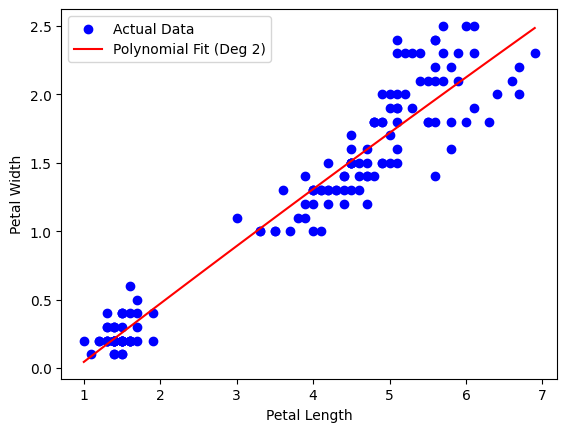

In [ ]:
# Create smooth line for plotting
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = np.c_[X_range, X_range**2]
X_range_scaled = scaler.transform(X_range_poly)
X_range_final = np.c_[np.ones((100, 1)), X_range_scaled]

predictions = model.predict(X_range_final)

# Plotting
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_range, predictions, color='red', label='Polynomial Fit (Deg 2)')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()
plt.show()

Visualization

We treated the non-linear problem as a linear one in a higher-dimensional space.

1. Feature Augmentation: We took a single dimension (Length) and projected it into two dimensions (Length, $Length^2$).

2. Linear Mapping: We found a flat plane in that 2D space. When we project that flat plane back down to our original 1D space, it appears as a parabola (a curve).     
3. Optimization: We used the same Gradient Descent logic. The model doesn't "know" it's doing polynomial regression; it just thinks it has two different independent features to weight.